<a href="https://colab.research.google.com/github/gustavo-mrcbg/app-ideas/blob/master/C%C3%B3pia_de_Hiperparametros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impacto dos Hiperparametros


*   Dados de duas classes
*   Classificador SVM
*   Parâmetros C e Gamma



In [ ]:
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Gerar dados simulados
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Função para plotar SVM com hiperparâmetros ajustáveis
def plot_svm(C=1.0, gamma=1.0):
    model = SVC(C=C, gamma=gamma, kernel='rbf')
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))

    plt.figure(figsize=(6, 5))
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f"SVM com C={C}, gamma={gamma} | Acc: {acc:.2f}")
    plt.tight_layout()
    plt.show()

# Widgets interativos
C_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=2, step=0.1, description='C')
gamma_slider = widgets.FloatLogSlider(value=0.001, base=10, min=-4, max=1, step=0.1, description='Gamma')

ui = widgets.VBox([C_slider, gamma_slider])
widgets.interact(plot_svm, C=C_slider, gamma=gamma_slider)

display(Markdown("""
### Explore a influência dos hiperparâmetros `C` e `gamma` no modelo SVM
- `C`: controla a penalidade por erro de classificação (trade-off bias-variance)
- `gamma`: controla o alcance da influência de cada ponto (quanto maior, mais sensível)
"""))


interactive(children=(FloatLogSlider(value=1.0, description='C', max=2.0, min=-2.0), FloatLogSlider(value=0.00…


### Explore a influência dos hiperparâmetros `C` e `gamma` no modelo SVM
- `C`: controla a penalidade por erro de classificação (trade-off bias-variance)
- `gamma`: controla o alcance da influência de cada ponto (quanto maior, mais sensível)


## Comparação entre Grid Search, Random Search e LHS

Grid Search: Tempo = 2871.12s, Acurácia = 0.9485, Best = {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Random Search: Tempo = 1808.68s, Acurácia = 0.9461, Best = {'max_depth': 19, 'min_samples_split': 4, 'n_estimators': 130}
LHS: Tempo = 876.33s, Acurácia = 0.9474, Best = {'n_estimators': 131, 'max_depth': 19, 'min_samples_split': 3}


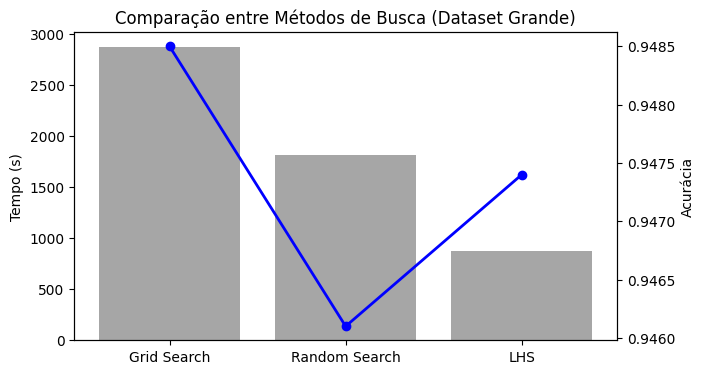

In [ ]:
# Experimento: Comparação entre Grid Search, Random Search e LHS
# Agora usando um dataset grande para destacar diferenças de tempo

## Bibliotecas
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint, qmc  # usamos qmc no lugar do pyDOE2

## Dados sintéticos grandes
X, y = make_classification(
    n_samples=50000,    # 50 mil amostras
    n_features=50,      # 50 atributos
    n_informative=25,   # metade informativa
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Espaço de busca (maior, para deixar Grid pesado)
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

## Grid Search
start = time.time()
grid = GridSearchCV(RandomForestClassifier(random_state=0), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - start
grid_best = grid.best_params_
grid_acc = accuracy_score(y_test, grid.predict(X_test))

## Random Search
param_dist = {
    'n_estimators': randint(50, 201),
    'max_depth': randint(5, 21),
    'min_samples_split': randint(2, 11)
}
start = time.time()
random = RandomizedSearchCV(RandomForestClassifier(random_state=0), param_dist, n_iter=20, cv=3, random_state=42, n_jobs=-1)
random.fit(X_train, y_train)
random_time = time.time() - start
random_best = random.best_params_
random_acc = accuracy_score(y_test, random.predict(X_test))

## LHS Search (manual usando scipy.stats.qmc)
sampler = qmc.LatinHypercube(d=3, seed=42)  # 3 parâmetros
lhs_samples = sampler.random(n=20)          # 20 amostras

lhs_grid = pd.DataFrame()
lhs_grid['n_estimators'] = (lhs_samples[:,0] * (200 - 50) + 50).astype(int)
lhs_grid['max_depth'] = (lhs_samples[:,1] * (20 - 5) + 5).astype(int)
lhs_grid['min_samples_split'] = (lhs_samples[:,2] * (10 - 2) + 2).astype(int)

best_score = 0
best_params = {}
start = time.time()
for _, row in lhs_grid.iterrows():
    model = RandomForestClassifier(
        n_estimators=row['n_estimators'],
        max_depth=row['max_depth'],
        min_samples_split=row['min_samples_split'],
        random_state=0,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    score = accuracy_score(y_test, model.predict(X_test))
    if score > best_score:
        best_score = score
        best_params = row
lhs_time = time.time() - start

## Resultados
print("Grid Search: Tempo = {:.2f}s, Acurácia = {:.4f}, Best = {}".format(grid_time, grid_acc, grid_best))
print("Random Search: Tempo = {:.2f}s, Acurácia = {:.4f}, Best = {}".format(random_time, random_acc, random_best))
print("LHS: Tempo = {:.2f}s, Acurácia = {:.4f}, Best = {}".format(lhs_time, best_score, best_params.to_dict()))

## Visualização
methods = ['Grid Search', 'Random Search', 'LHS']
times = [grid_time, random_time, lhs_time]
accs = [grid_acc, random_acc, best_score]

fig, ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
ax1.bar(methods, times, color='gray', alpha=0.7, label='Tempo (s)')
ax2.plot(methods, accs, color='blue', marker='o', linewidth=2, label='Acurácia')

ax1.set_ylabel('Tempo (s)')
ax2.set_ylabel('Acurácia')
ax1.set_title('Comparação entre Métodos de Busca (Dataset Grande)')
plt.show()


## Exemplo com Optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 16.0 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification


# 1. Carregar os dados


## Dados sintéticos
X, y = make_classification(
    n_samples=50000,    # 50 mil amostras
    n_features=50,      # 50 atributos
    n_informative=25,   # metade informativa
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 2. Definir a função objetivo que o Optuna irá otimizar
def objective(trial):
    # Sugestões de hiperparâmetros
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    # Criar e treinar o modelo
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Avaliar no conjunto de teste
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Retornar erro (Optuna minimiza por padrão)
    return 1.0 - accuracy

# 3. Criar o estudo e iniciar a otimização
study = optuna.create_study(direction="minimize")  # Minimiza o erro
study.optimize(objective, n_trials=30)

# 4. Exibir os melhores resultados
print("Melhores hiperparâmetros:", study.best_params)
print("Melhor acurácia:", 1.0 - study.best_value)

optuna.visualization.plot_param_importances(study)


[I 2025-09-16 17:13:16,326] A new study created in memory with name: no-name-28d895d2-5ef9-407a-bc4b-9326f49fbf3e
[I 2025-09-16 17:14:05,930] Trial 0 finished with value: 0.10270000000000001 and parameters: {'n_estimators': 108, 'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.10270000000000001.
[I 2025-09-16 17:15:21,555] Trial 1 finished with value: 0.07989999999999997 and parameters: {'n_estimators': 171, 'max_depth': 10, 'min_samples_split': 8}. Best is trial 1 with value: 0.07989999999999997.
[I 2025-09-16 17:16:46,107] Trial 2 finished with value: 0.05030000000000001 and parameters: {'n_estimators': 143, 'max_depth': 19, 'min_samples_split': 7}. Best is trial 2 with value: 0.05030000000000001.
[I 2025-09-16 17:17:34,163] Trial 3 finished with value: 0.13560000000000005 and parameters: {'n_estimators': 166, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 2 with value: 0.05030000000000001.
[I 2025-09-16 17:18:04,646] Trial 4 finished with value: 0.13729

Melhores hiperparâmetros: {'n_estimators': 143, 'max_depth': 19, 'min_samples_split': 7}
Melhor acurácia: 0.9497


# Early Stopping - Rede Neural

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.




Epoch 1: val_loss improved from inf to 0.11345, saving model to best_model.h5



Epoch 2: val_loss improved from 0.11345 to 0.08986, saving model to best_model.h5



Epoch 3: val_loss improved from 0.08986 to 0.08461, saving model to best_model.h5



Epoch 4: val_loss did not improve from 0.08461

Epoch 5: val_loss improved from 0.08461 to 0.07607, saving model to best_model.h5



Epoch 6: val_loss improved from 0.07607 to 0.07509, saving model to best_model.h5



Epoch 7: val_loss improved from 0.07509 to 0.07506, saving model to best_model.h5



Epoch 8: val_loss improved from 0.07506 to 0.07454, saving model to best_model.h5



Epoch 9: val_loss did not improve from 0.07454

Epoch 10: val_loss did not improve from 0.07454

Epoch 11: val_loss did not improve from 0.07454

Epoch 12: val_loss did not improve from 0.07454

Epoch 13: val_loss did not improve from 0.07454
Treinou por 13 épocas
Melhor época (menor val_loss): 8
Treinamento parou na época: 13


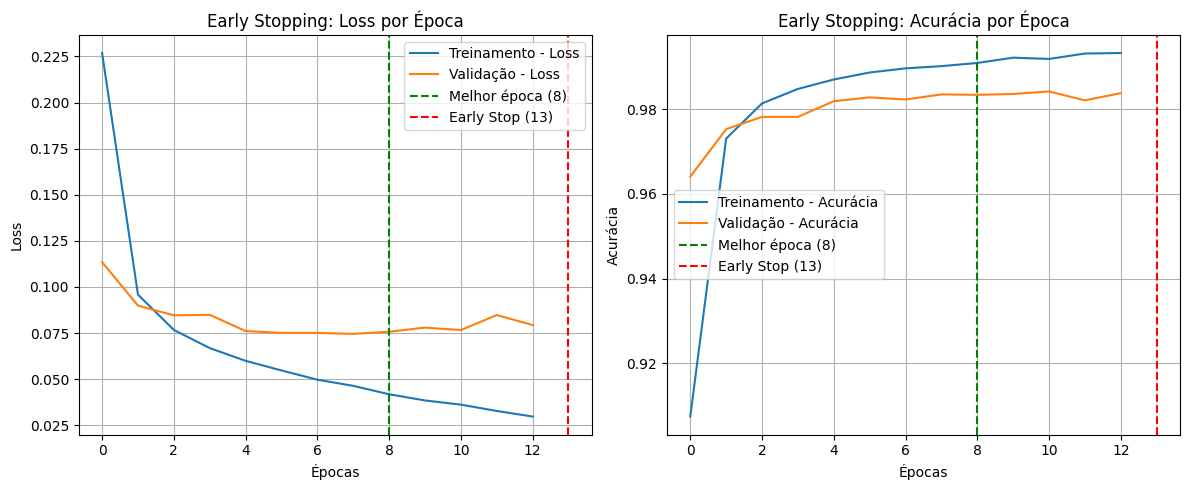

Acurácia do modelo carregado do arquivo: 0.9835


In [ ]:
# Exemplo completo: EarlyStopping + ModelCheckpoint em Keras

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ================================================================
# 1. Gerar dados sintéticos
# ================================================================
X, y = make_classification(
    n_samples=50000,    # 50 mil amostras
    n_features=50,      # 50 atributos
    n_informative=25,   # metade informativa
    n_classes=2,
    random_state=42
)

# ================================================================
# 2. Pré-processamento
# ================================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# ================================================================
# 3. Construção do modelo
# ================================================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ================================================================
# 4. Callbacks: EarlyStopping + ModelCheckpoint
# ================================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="best_model.h5",   # arquivo para salvar
    monitor="val_loss",
    save_best_only=True,        # salva só o melhor
    save_weights_only=False,    # False = salva modelo completo
    verbose=1
)

# ================================================================
# 5. Treinamento
# ================================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=0
)

# ================================================================
# 6. Análise do treinamento
# ================================================================
n_epochs = len(history.history["loss"])
best_epoch = np.argmin(history.history["val_loss"]) + 1
stop_epoch = n_epochs

print(f"Treinou por {n_epochs} épocas")
print(f"Melhor época (menor val_loss): {best_epoch}")
print(f"Treinamento parou na época: {stop_epoch}")

# ================================================================
# 7. Gráficos: Loss e Acurácia
# ================================================================
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento - Loss')
plt.plot(history.history['val_loss'], label='Validação - Loss')
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Melhor época ({best_epoch})')
plt.axvline(stop_epoch, color='red', linestyle='--', label=f'Early Stop ({stop_epoch})')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Early Stopping: Loss por Época')
plt.legend()
plt.grid()

# Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento - Acurácia')
plt.plot(history.history['val_accuracy'], label='Validação - Acurácia')
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Melhor época ({best_epoch})')
plt.axvline(stop_epoch, color='red', linestyle='--', label=f'Early Stop ({stop_epoch})')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.title('Early Stopping: Acurácia por Época')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ================================================================
# 8. Carregar o melhor modelo salvo e avaliar
# ================================================================
best_model = load_model("best_model.h5")
loss, acc = best_model.evaluate(X_val, y_val, verbose=0)
print(f"Acurácia do modelo carregado do arquivo: {acc:.4f}")


## Early Stopping no XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
#from sklearn.datasets import load_breast_cancer

# Dados
#X, y = load_breast_cancer(return_X_y=True)
#X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Treino com early stopping
params = {"objective": "binary:logistic", "eval_metric": "logloss"}
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,               # máximo de árvores
    evals=[(dval, "validation")],       # conjunto de validação
    early_stopping_rounds=10,           # para se não melhorar em 10 rodadas
    verbose_eval=False
)

print(f"Treinou até a iteração: {bst.best_iteration}")

Treinou até a iteração: 238


# Particle Swarm Optimization

In [ ]:
!pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pyswarms as ps

# ==============================
# 1. Dataset
# ==============================
X, y = make_classification(
	n_samples=50000,
	n_features=50,
	n_informative=25,
	n_classes=2,
	random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

# ==============================
# 2. Objective function for PSO
# ==============================
def objective_function(params):
	# params.shape = (n_particles, n_dimensions)
	scores = []
	for p in params:
		# Map continuous values to integers within bounds
		n_estimators = int(p[0])
		max_depth = int(p[1])
		min_samples_split = int(p[2])

		# Build and evaluate the Random Forest
		model = RandomForestClassifier(
			n_estimators=n_estimators,
			max_depth=max_depth,
			min_samples_split=min_samples_split,
			random_state=42,
			n_jobs=-1
		)
		model.fit(X_train, y_train)
		preds = model.predict(X_test)
		acc = accuracy_score(y_test, preds)

		# PSO minimizes -> use negative accuracy
		scores.append(-acc)
	return np.array(scores)

# ==============================
# 3. PSO optimization
# ==============================

# Define search space: [n_estimators, max_depth, min_samples_split]
# Bounds are continuous, but we’ll cast to int inside the objective
bounds = (
	np.array([50, 2, 2]),   # min values
	np.array([200, 20, 10]) # max values
)

# PSO optimizer
optimizer = ps.single.GlobalBestPSO(
	n_particles=10,      # number of candidate solutions
	dimensions=3,        # three hyperparameters
	options={'c1': 0.5, 'c2': 0.3, 'w': 0.9},  # cognitive, social, inertia
	bounds=bounds
)

# Run optimization (each iteration evaluates all particles)
best_cost, best_pos = optimizer.optimize(objective_function, iters=5)

# ==============================
# 4. Results
# ==============================
print("Best parameters found by PSO:")
print(f"n_estimators     = {int(best_pos[0])}")
print(f"max_depth        = {int(best_pos[1])}")
print(f"min_samples_split= {int(best_pos[2])}")
print(f"Best accuracy    = {-best_cost:.4f}")


2025-09-19 12:52:08,994 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|5/5, best_cost=-0.949
2025-09-19 13:41:09,526 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.9494, best pos: [180.79500172  17.27574642   7.71776402]


Best parameters found by PSO:
n_estimators     = 180
max_depth        = 17
min_samples_split= 7
Best accuracy    = 0.9494
